In [1]:
#Import all packages
import os
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import folium
import contextily as ctx
import scipy.stats
import scipy.interpolate
import tqdm
from pathlib import Path
import xarray as xr
import skgstat as skg
import seaborn as sns
import pysal
from pysal.explore import esda
from pysal.lib import weights
from splot.esda import moran_scatterplot
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib_scalebar.scalebar import ScaleBar
import rasterio
from rasterio.plot import show
import rasterio
import xarray as xr
import numpy as np
from pathlib import Path
import re
from datetime import datetime
import geopandas as gpd
import re
from datetime import datetime
import numpy as np
import xarray as xr
import rasterio
from rasterio.features import rasterize
from shapely.geometry import mapping
from shapely.geometry import LineString, Point, MultiPoint, GeometryCollection
import shapely.ops as ops
import pandas as pd
import numpy as np
import geopandas as gpd
from scipy.optimize import curve_fit

/opt/conda/lib/python3.11/site-packages/spaghetti/network.py:41: FutureWarning: The next major release of pysal/spaghetti (2.0.0) will drop support for all ``libpysal.cg`` geometries. This change is a first step in refactoring ``spaghetti`` that is expected to result in dramatically reduced runtimes for network instantiation and operations. Users currently requiring network and point pattern input as ``libpysal.cg`` geometries should prepare for this simply by converting to ``shapely`` geometries.
  warnings.warn(dep_msg, FutureWarning, stacklevel=1)


In [2]:
#SUMMON THE DATA
final_df = pd.read_csv("/home/jovyan/Society_of_Bouy_Cowboys/Data/Organized_Data/final_df.csv")
final_df
final_ds = xr.open_dataset("/home/jovyan/Society_of_Bouy_Cowboys/Data/Organized_Data/final_ds.nc")
final_ds

<xarray.Dataset> Size: 82kB
Dimensions:           (source: 4, time: 928)
Coordinates:
  * source            (source) <U4 64B 'S1P1' 'S1P2' 'S1P3' 'S1A1'
  * time              (time) datetime64[ns] 7kB 2019-11-09T20:30:00 ... 2019-...
Data variables:
    wave_height_m     (source, time) float64 30kB ...
    moor_dist_m       (source) float64 32B ...
    moor_dist_km      (source) float64 32B ...
    moor_lat          (source) float64 32B ...
    moor_lon          (source) float64 32B ...
    ice_edge_dist_m   (time) float64 7kB ...
    ice_edge_dist_km  (time) float64 7kB ...
    dist_from_ice     (time, source) float64 30kB ...
Attributes:
    crs:             EPSG:32604
    reference_axis:  Distance along mooring transect, zeroed at POINT (387833...

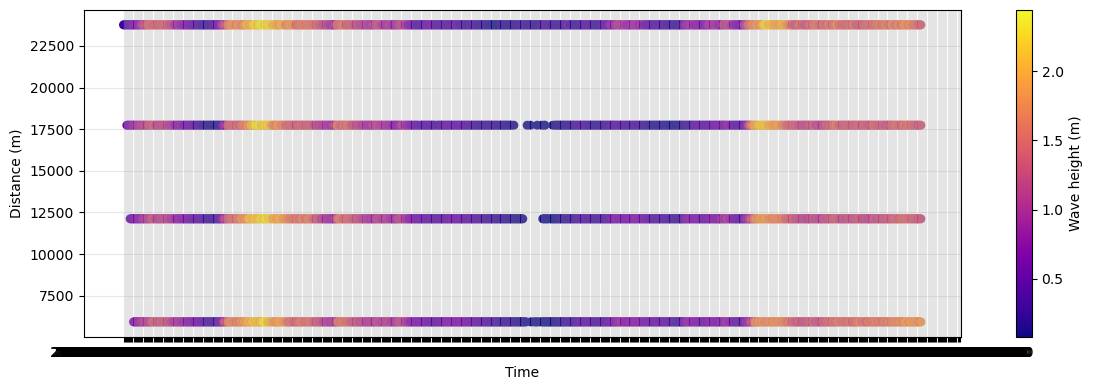

In [3]:
#Wave Height Over Time Plot
S1P1= final_df[final_df['source']=='S1P1']
S1P2= final_df[final_df['source']=='S1P2']
S1P3= final_df[final_df['source']=='S1P3']
S1A1= final_df[final_df['source']=='S1A1']


f, ax = plt.subplots(1,1, figsize=(12,4))
sc_P1=ax.scatter(S1P1['time'], S1P1['moor_dist_m'], c=S1P1['wave_height_m'], cmap='plasma', s=30)
plt.colorbar(sc_P1, ax=ax, label="Wave height (m)")

sc_P2=ax.scatter(S1P2['time'], S1P2['moor_dist_m'], c=S1P2['wave_height_m'], cmap='plasma', s=30)


sc_P3=ax.scatter(S1P3['time'], S1P3['moor_dist_m'], c=S1P3['wave_height_m'], cmap='plasma', s=30)

sc_A1=ax.scatter(S1A1['time'], S1A1['moor_dist_m'], c=S1A1['wave_height_m'], cmap='plasma', s=30)

ax.set_xlabel("Time")
ax.set_ylabel("Distance (m)")




ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




In [4]:
final_df['ice_edge_dist_m']

0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
        ..
3707   NaN
3708   NaN
3709   NaN
3710   NaN
3711   NaN
Name: ice_edge_dist_m, Length: 3712, dtype: float64

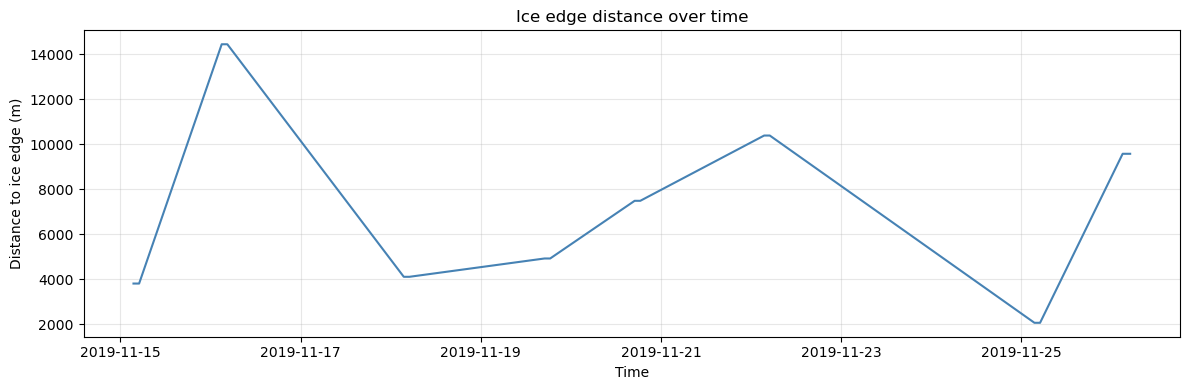

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(final_ds["time"], final_ds["ice_edge_dist_m"], color="steelblue", linewidth=1.5)

ax.set_xlabel("Time")
ax.set_ylabel("Distance to ice edge (m)")
ax.set_title("Ice edge distance over time")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
final_ds["ice_edge_dist_m"] = final_ds["ice_edge_dist_m"].interpolate_na(dim="time", method="linear")

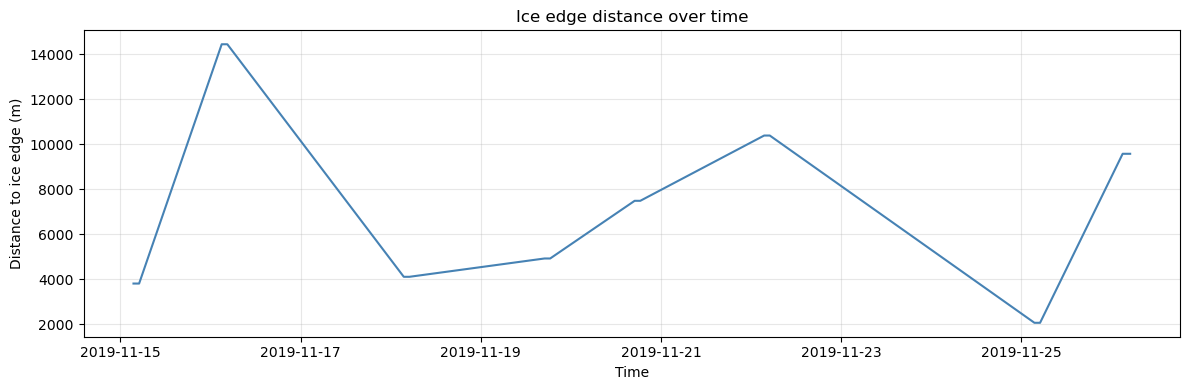

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(final_ds["time"], final_ds["ice_edge_dist_m"], color="steelblue", linewidth=1.5)

ax.set_xlabel("Time")
ax.set_ylabel("Distance to ice edge (m)")
ax.set_title("Ice edge distance over time")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

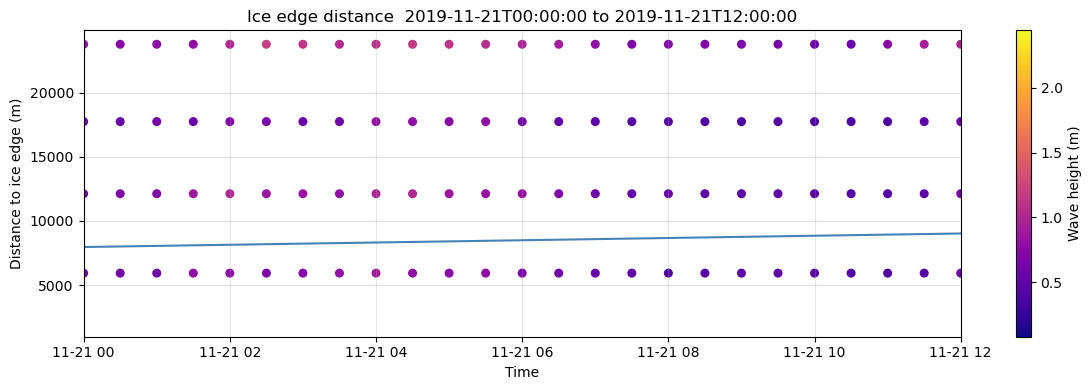

In [16]:
#Want an adjustable time scale to see which section is going to give the best results
TIME_START = "2019-11-21T00:00:00"
TIME_END   = "2019-11-21T12:00:00"

ds_slice = final_ds.sel(time=slice(TIME_START, TIME_END))

times = pd.to_datetime(final_ds["time"].values)
dist  = final_ds["ice_edge_dist_m"].values

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(final_ds["time"], final_ds["ice_edge_dist_m"], color="steelblue", linewidth=1.5)
sc_P1 = ax.scatter(S1P1["time"], S1P1["moor_dist_m"], c=S1P1["wave_height_m"], cmap="plasma", s=30)
sc_P2 = ax.scatter(S1P2["time"], S1P2["moor_dist_m"], c=S1P2["wave_height_m"], cmap="plasma", s=30)
sc_P3 = ax.scatter(S1P3["time"], S1P3["moor_dist_m"], c=S1P3["wave_height_m"], cmap="plasma", s=30)
sc_A1 = ax.scatter(S1A1["time"], S1A1["moor_dist_m"], c=S1A1["wave_height_m"], cmap="plasma", s=30)

plt.colorbar(sc_P1, ax=ax, label="Wave height (m)")
ax.set_xlim(pd.Timestamp(TIME_START), pd.Timestamp(TIME_END))
ax.set_xlabel("Time")
ax.set_ylabel("Distance to ice edge (m)")
ax.set_title(f"Ice edge distance  {TIME_START} to {TIME_END}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

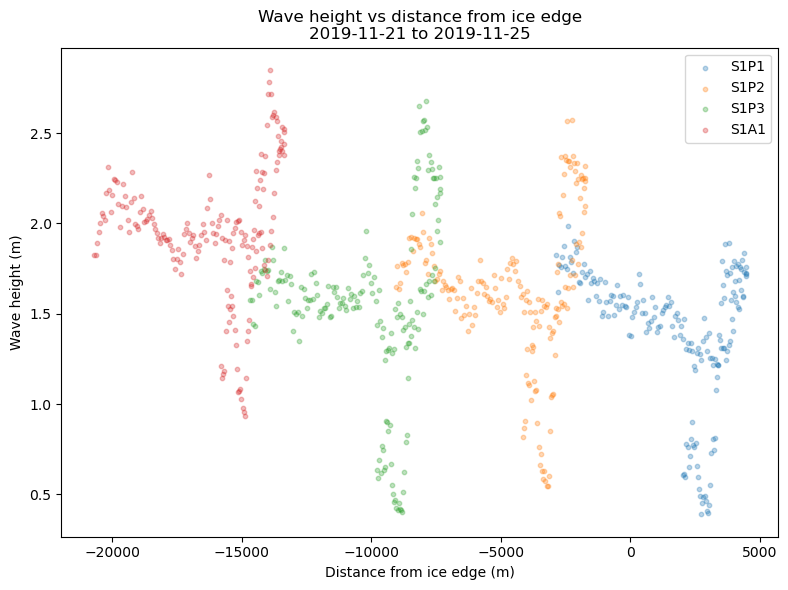

In [9]:
#Want an adjustable time scale to see which section is going to give the best results
TIME_START = "2019-11-21"
TIME_END   = "2019-11-25"

ds_slice = final_ds.sel(time=slice(TIME_START, TIME_END))

fig, ax = plt.subplots(figsize=(8, 6))

for source in ds_slice.source.values:
    wave = ds_slice["wave_height_m"].sel(source=source).values
    dist = ds_slice["dist_from_ice"].sel(source=source).values

    ax.scatter(
        dist,
        wave,
        label = source,
        alpha = 0.3,
        s     = 10,
    )

ax.set_xlabel("Distance from ice edge (m)")
ax.set_ylabel("Wave height (m)")
ax.set_title(f"Wave height vs distance from ice edge\n{TIME_START} to {TIME_END}")
ax.legend()
plt.tight_layout()
plt.show()

H0    = 0.7856 m
alpha = 0.000031 m⁻¹
decay length = 32.05 km


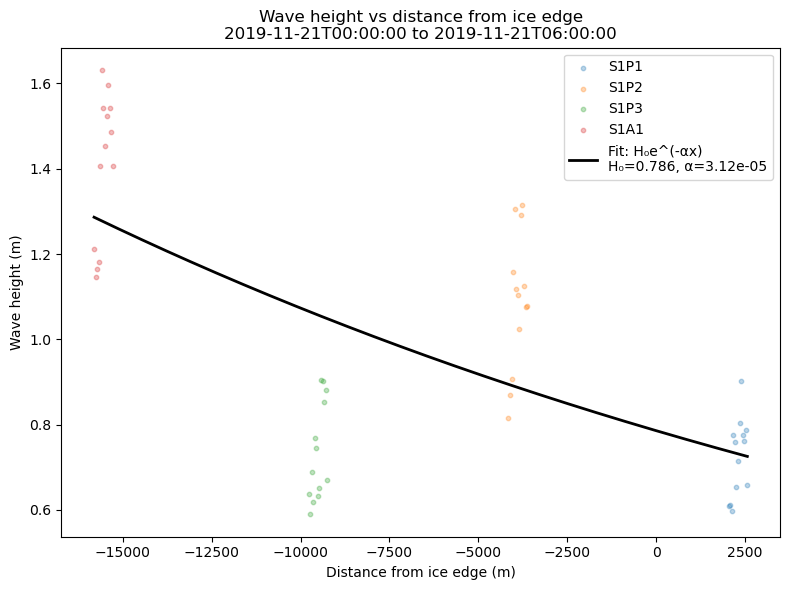

In [18]:
#Keep Adjustable Time Scale
TIME_START = "2019-11-21T00:00:00"
TIME_END   = "2019-11-21T06:00:00"

ds_slice = final_ds.sel(time=slice(TIME_START, TIME_END))

#Seperate wave and distance data 
all_dist = []
all_wave = []

for source in ds_slice.source.values:
    wave = ds_slice["wave_height_m"].sel(source=source).values
    dist = ds_slice["dist_from_ice"].sel(source=source).values
    
    # Remove NaNs
    mask = np.isfinite(wave) & np.isfinite(dist)
    all_dist.extend(dist[mask])
    all_wave.extend(wave[mask])

all_dist = np.array(all_dist)
all_wave = np.array(all_wave)

#Create line of best fit 
def exponential_decay(x, H0, alpha):
    return H0 * np.exp(-alpha * x)

popt, pcov = curve_fit( exponential_decay, all_dist, all_wave,
    p0     = [all_wave.max(), 1e-7],   # initial guess 
                      )

H0, alpha = popt
print(f"H0    = {H0:.4f} m")
print(f"alpha = {alpha:.6f} m⁻¹")
print(f"decay length = {1/alpha/1000:.2f} km")

#Create Plot
fig, ax = plt.subplots(figsize=(8, 6))

for source in ds_slice.source.values:
    wave = ds_slice["wave_height_m"].sel(source=source).values
    dist = ds_slice["dist_from_ice"].sel(source=source).values
    mask = np.isfinite(wave) & np.isfinite(dist)
    ax.scatter(dist[mask], wave[mask], label=source, alpha=0.3, s=10)

# Fit line
x_fit = np.linspace(all_dist.min(), all_dist.max(), 300)
y_fit = exponential_decay(x_fit, H0, alpha)
ax.plot(x_fit, y_fit, color="black", linewidth=2,
        label=f"Fit: H₀e^(-αx)\nH₀={H0:.3f}, α={alpha:.2e}")

ax.set_xlabel("Distance from ice edge (m)")
ax.set_ylabel("Wave height (m)")
ax.set_title(f"Wave height vs distance from ice edge\n{TIME_START} to {TIME_END}")
ax.legend()
plt.tight_layout()
plt.show()

H0    = 1.4030 m
alpha = 0.000017 m⁻¹
decay length = 57.99 km


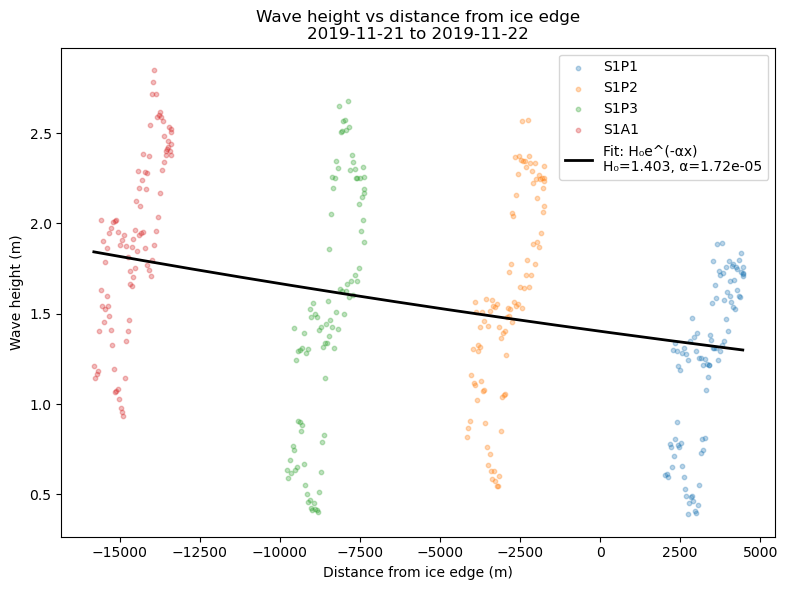

In [12]:
#Keep Adjustable Time Scale
TIME_START = "2019-11-21"
TIME_END   = "2019-11-22"

ds_slice = final_ds.sel(time=slice(TIME_START, TIME_END))

#Seperate wave and distance data 
all_dist = []
all_wave = []

for source in ds_slice.source.values:
    wave = ds_slice["wave_height_m"].sel(source=source).values
    dist = ds_slice["dist_from_ice"].sel(source=source).values
    
    # Remove NaNs
    mask = np.isfinite(wave) & np.isfinite(dist)
    all_dist.extend(dist[mask])
    all_wave.extend(wave[mask])

all_dist = np.array(all_dist)
all_wave = np.array(all_wave)

#Create line of best fit 
def exponential_decay(x, H0, alpha):
    return H0 * np.exp(-alpha * x)

popt, pcov = curve_fit( exponential_decay, all_dist, all_wave,
    p0     = [all_wave.max(), 1e-7],   # initial guess 
                      )

H0, alpha = popt
print(f"H0    = {H0:.4f} m")
print(f"alpha = {alpha:.6f} m⁻¹")
print(f"decay length = {1/alpha/1000:.2f} km")

#Create Plot
fig, ax = plt.subplots(figsize=(8, 6))

for source in ds_slice.source.values:
    wave = ds_slice["wave_height_m"].sel(source=source).values
    dist = ds_slice["dist_from_ice"].sel(source=source).values
    mask = np.isfinite(wave) & np.isfinite(dist)
    ax.scatter(dist[mask], wave[mask], label=source, alpha=0.3, s=10)

# Fit line
x_fit = np.linspace(all_dist.min(), all_dist.max(), 300)
y_fit = exponential_decay(x_fit, H0, alpha)
ax.plot(x_fit, y_fit, color="black", linewidth=2,
        label=f"Fit: H₀e^(-αx)\nH₀={H0:.3f}, α={alpha:.2e}")

ax.set_xlabel("Distance from ice edge (m)")
ax.set_ylabel("Wave height (m)")
ax.set_title(f"Wave height vs distance from ice edge\n{TIME_START} to {TIME_END}")
ax.legend()
plt.tight_layout()
plt.show()